# **Predicting Trading Signals**

## **Introduction**

Through this project we will develop and evaluate supervised machine learning models to predict ’buy’ and ’sell’ signals for stocks, using manually computed technical indicators such as MACD, RSI, and Bollinger Bands. We will use the prepared data from project 2. 

### **Load the prepared dataset**

In [2]:
# Import libraries
import pandas as pd
import numpy as np


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)
from sklearn.metrics import precision_score, recall_score, f1_score

In [4]:
# Import the prepared dataset from Project 2

stock_data = pd.read_csv(
    "../Project_2_DataCleaning_Preparation/stock_prepared.csv")

In [5]:
stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20860334 entries, 0 to 20860333
Data columns (total 29 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   ticker                        str    
 1   date                          str    
 2   open                          float64
 3   high                          float64
 4   low                           float64
 5   close                         float64
 6   volume                        int64  
 7   price_change                  float64
 8   daily_return                  float64
 9   close_lag_1                   float64
 10  ma_5                          float64
 11  ma_20                         float64
 12  volatility_20                 float64
 13  avg_volume_20                 float64
 14  exchange_NASDAQ               int64  
 15  exchange_NYSE                 int64  
 16  sector_BASIC INDUSTRIES       int64  
 17  sector_CAPITAL GOODS          int64  
 18  sector_CONSUMER DURABLES      i

In [6]:
# Convert date to date time

stock_data["date"] = pd.to_datetime(stock_data["date"])

In [7]:
stock_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20860334 entries, 0 to 20860333
Data columns (total 29 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   ticker                        str           
 1   date                          datetime64[us]
 2   open                          float64       
 3   high                          float64       
 4   low                           float64       
 5   close                         float64       
 6   volume                        int64         
 7   price_change                  float64       
 8   daily_return                  float64       
 9   close_lag_1                   float64       
 10  ma_5                          float64       
 11  ma_20                         float64       
 12  volatility_20                 float64       
 13  avg_volume_20                 float64       
 14  exchange_NASDAQ               int64         
 15  exchange_NYSE                 int64      

## **Part 1 — Create Technical Indicators**

#### **1.1 Calculate MACD**

In [8]:
# Order the data by ticker an date

stock_data = stock_data.sort_values(["ticker", "date"])

In [9]:
# calculate the 12-day window Exponential Moving Average (EMA) of close

stock_data["EMA12"] = (
    stock_data.groupby("ticker")["close"]
    .transform(lambda x: x.ewm(span=12, adjust=False).mean()))

In [10]:
# Calculate 26-day window EMA

stock_data["EMA26"] = (
    stock_data.groupby("ticker")["close"]
    .transform(lambda x: x.ewm(span=26, adjust=False).mean()))

In [11]:
# Calculate MACD line

stock_data["MACD"] = (
    stock_data["EMA12"] - stock_data["EMA26"])

In [12]:
# Calculate 9-day EMA of MACD (Signal line)

stock_data["Signal_Line"] = (
    stock_data.groupby("ticker")["MACD"]
    .transform(lambda x: x.ewm(span=9, adjust=False).mean()))

In [13]:
stock_data[
    ["ticker", "date", "close", "EMA12", "EMA26", "MACD", "Signal_Line"]
].head(30)

,ticker,date,close,EMA12,EMA26,MACD,Signal_Line
0,A,1999-12-17,32.859444,32.859444,32.859444,0.000000,0.000000
1,A,1999-12-20,33.530045,32.962613,32.909118,0.053495,0.010699
2,A,1999-12-21,33.351215,33.022398,32.941866,0.080532,0.024666
3,A,1999-12-22,34.021816,33.176155,33.021862,0.154293,0.050591
4,A,1999-12-23,35.586552,33.546985,33.211839,0.335146,0.107502
5,A,1999-12-27,37.777184,34.197785,33.550013,0.647772,0.215556
6,A,1999-12-28,43.991417,35.704497,34.323450,1.381047,0.448654
7,A,1999-12-29,51.502148,38.134905,35.595946,2.538959,0.866715
8,A,1999-12-30,56.688126,40.989247,37.158330,3.830917,1.459556
9,A,1999-12-31,55.302216,43.191242,38.502321,4.688921,2.105429


### **Create and Compare the MACD line with its signal line.**

In [14]:
# Get previous MACD and Signal Line

stock_data["prev_MACD"] = stock_data.groupby("ticker")["MACD"].shift(1)
stock_data["prev_Signal"] = stock_data.groupby("ticker")["Signal_Line"].shift(1)

In [15]:
# Create Buy, Sell, and Hold conditions

# Define crossover conditions
buy_condition = (
    (stock_data["prev_MACD"] < stock_data["prev_Signal"]) &
    (stock_data["MACD"] > stock_data["Signal_Line"]))

sell_condition = (
    (stock_data["prev_MACD"] > stock_data["prev_Signal"]) &
    (stock_data["MACD"] < stock_data["Signal_Line"]))

In [16]:
# Create MACD signal

stock_data["MACD_Signal"] = "Hold"

stock_data.loc[buy_condition, "MACD_Signal"] = "Buy"
stock_data.loc[sell_condition, "MACD_Signal"] = "Sell"

In [17]:
# Check the results

stock_data[
    ["ticker", "date", "MACD", "Signal_Line",
     "prev_MACD", "prev_Signal", "MACD_Signal"]
].head(30)

,ticker,date,MACD,Signal_Line,prev_MACD,prev_Signal,MACD_Signal
0,A,1999-12-17,0.000000,0.000000,NaN,NaN,Hold
1,A,1999-12-20,0.053495,0.010699,0.000000,0.000000,Hold
2,A,1999-12-21,0.080532,0.024666,0.053495,0.010699,Hold
3,A,1999-12-22,0.154293,0.050591,0.080532,0.024666,Hold
4,A,1999-12-23,0.335146,0.107502,0.154293,0.050591,Hold
5,A,1999-12-27,0.647772,0.215556,0.335146,0.107502,Hold
6,A,1999-12-28,1.381047,0.448654,0.647772,0.215556,Hold
7,A,1999-12-29,2.538959,0.866715,1.381047,0.448654,Hold
8,A,1999-12-30,3.830917,1.459556,2.538959,0.866715,Hold
9,A,1999-12-31,4.688921,2.105429,3.830917,1.459556,Hold


In [18]:
stock_data["MACD_Signal"].value_counts()

MACD_Signal
Hold    19123625
Buy       868779
Sell      867930
Name: count, dtype: int64

#### **Insights**:

We calculated the MACD (Moving Average Convergence Divergence) separately for each stock using its closing price. First, we calculated the 12-day EMA (EMA12) and 26-day EMA (EMA26). We then calculated the MACD line as the difference between these two moving averages

Next, we calculated the Signal Line as the 9-day EMA of the MACD. We then compared the current and previous MACD and Signal Line values to identify crossovers. A Buy signal was generated when MACD crossed above the Signal Line, a Sell signal when MACD crossed below it, and Hold when neither crossover occurred.

These signals describe MACD-based trading conditions according to the rules defined for this project and are not guarantees of future stock-price movements.

### **1.2 Calculate RSI**

In [19]:
# Calculate price change

stock_data["RSI_change"] = stock_data.groupby("ticker")["close"].diff()

In [20]:
# Separate gains and losses

stock_data["gain"] = stock_data["RSI_change"].clip(lower=0)
stock_data["loss"] = -stock_data["RSI_change"].clip(upper=0)

In [21]:
# Calculate 14-day exponential average gain

stock_data["avg_gain"] = (
    stock_data.groupby("ticker")["gain"]
    .transform(lambda x: x.ewm(span=14, adjust=False).mean()))

In [22]:
# Calculate 14-day exponential average loss

stock_data["avg_loss"] = (
    stock_data.groupby("ticker")["loss"]
    .transform(lambda x: x.ewm(span=14, adjust=False).mean()))

In [23]:
# Calculate Relative Strength

stock_data["RS"] = stock_data["avg_gain"] / stock_data["avg_loss"]

In [24]:
# Calculate RSI

stock_data["RSI"] = 100 - (100 / (1 + stock_data["RS"]))

In [25]:
# Create RSI signal
stock_data["RSI_Signal"] = "Hold"

stock_data.loc[stock_data["RSI"] < 30, "RSI_Signal"] = "Buy"
stock_data.loc[stock_data["RSI"] > 70, "RSI_Signal"] = "Sell"

In [26]:
# Check the results

stock_data[
    ["ticker", "date", "close", "RSI_change",
     "gain", "loss", "avg_gain", "avg_loss",
     "RS", "RSI", "RSI_Signal"]
].head(30)

,ticker,date,close,RSI_change,gain,loss,avg_gain,avg_loss,RS,RSI,RSI_Signal
0,A,1999-12-17,32.859444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hold
1,A,1999-12-20,33.530045,0.670601,0.670601,-0.000000,0.670601,-0.000000,-inf,100.000000,Sell
2,A,1999-12-21,33.351215,-0.178829,0.000000,0.178829,0.581187,0.023844,24.374688,96.059065,Sell
3,A,1999-12-22,34.021816,0.670601,0.670601,-0.000000,0.593109,0.020665,28.701556,96.633173,Sell
4,A,1999-12-23,35.586552,1.564735,1.564735,-0.000000,0.722659,0.017909,40.350815,97.581668,Sell
5,A,1999-12-27,37.777184,2.190632,2.190632,-0.000000,0.918389,0.015521,59.168869,98.338011,Sell
6,A,1999-12-28,43.991417,6.214233,6.214233,-0.000000,1.624502,0.013452,120.763204,99.178734,Sell
7,A,1999-12-29,51.502148,7.510731,7.510731,-0.000000,2.409332,0.011658,206.661255,99.518447,Sell
8,A,1999-12-30,56.688126,5.185978,5.185978,-0.000000,2.779552,0.010104,275.096478,99.637808,Sell
9,A,1999-12-31,55.302216,-1.385910,0.000000,1.385910,2.408945,0.193545,12.446450,92.563093,Sell


In [27]:
# Check the signal distribution

stock_data["RSI_Signal"].value_counts()

RSI_Signal
Hold    16051721
Sell     2696316
Buy      2112297
Name: count, dtype: int64

#### **Insights:**

We calculated the RSI (Relative Strength Index) separately for each stock using changes in its closing price. First, we calculated the daily price changes and separated them into gains and losses. We then calculated the 14-day exponential average gain and average loss.

Next, we calculated the Relative Strength (RS) and used it to calculate the RSI, which ranges from 0 to 100.

Finally, we created the RSI signals according to the project rules. An RSI below 30 generated a Buy signal, an RSI above 70 generated a Sell signal, and values between 30 and 70 generated a Hold signal.

These signals represent overbought and oversold conditions according to the RSI rules used in this project and do not guarantee future stock-price movements.

### **1.3 Create the Combined Trading Signal**

In [28]:
# Create final trading signal

stock_data["Final_Signal"] = "Hold"

stock_data.loc[
    (stock_data["MACD_Signal"] == "Buy") &
    (stock_data["RSI_Signal"] == "Buy"),
    "Final_Signal"
] = "Buy"

stock_data.loc[
    (stock_data["MACD_Signal"] == "Sell") &
    (stock_data["RSI_Signal"] == "Sell"),
    "Final_Signal"
] = "Sell"

In [29]:
# Check signal

stock_data[
    ["ticker", "date", "MACD_Signal", "RSI_Signal", "Final_Signal"]
].head(30)

,ticker,date,MACD_Signal,RSI_Signal,Final_Signal
0,A,1999-12-17,Hold,Hold,Hold
1,A,1999-12-20,Hold,Sell,Hold
2,A,1999-12-21,Hold,Sell,Hold
3,A,1999-12-22,Hold,Sell,Hold
4,A,1999-12-23,Hold,Sell,Hold
5,A,1999-12-27,Hold,Sell,Hold
6,A,1999-12-28,Hold,Sell,Hold
7,A,1999-12-29,Hold,Sell,Hold
8,A,1999-12-30,Hold,Sell,Hold
9,A,1999-12-31,Hold,Sell,Hold


In [30]:
stock_data["Final_Signal"].value_counts()

Final_Signal
Hold    20845824
Sell        7435
Buy         7075
Name: count, dtype: int64

#### **Insights:**

The combined trading rules generated 7,075 Buy, 7,435 Sell, and 20,845,824 Hold signals with Hold occuring by far the most frequently (Table 1). Buy and Sell are rare because both MACD and RSI must agree at the same time. If they do not agree, the final signal is classified as Hold. The target variable is highly imbalanced, with Hold representing almost all observations. This is important for the machine-learning stage because a model could achieve very high accuracy simply by predicting Hold most of the time

## **Part 2 — Check for Class Imbalance**

In [31]:
# Display class counts

class_counts = stock_data["Final_Signal"].value_counts()
print(class_counts)

Final_Signal
Hold    20845824
Sell        7435
Buy         7075
Name: count, dtype: int64


In [32]:
# Display class percentages

class_percentages = stock_data["Final_Signal"].value_counts(normalize=True) * 100
print(class_percentages)

Final_Signal
Hold    99.930442
Sell     0.035642
Buy      0.033916
Name: proportion, dtype: float64


## **Part 3 — Prepare the Data for Machine Learning**

In [33]:
# Calculate daily range percentage

stock_data["daily_range_pct"] = (
    (stock_data["high"] - stock_data["low"]) / stock_data["close"]) * 100

In [34]:
# Select features

features = [
    "daily_return",
    "close_lag_1",
    "ma_5",
    "ma_20",
    "volatility_20",
    "daily_range_pct"]

X = stock_data[features]

In [35]:
# Encode the target variable

# Encode the target variable
signal_mapping = {
    "Hold": 0,
    "Buy": 1,
    "Sell": 2}

stock_data["trading_signal"] = stock_data["Final_Signal"].map(signal_mapping)

y = stock_data["trading_signal"]

#### **Insights**

We prepared the data for machine learning by selecting the six predictor features: daily_return, close_lag_1, ma_5, ma_20, volatility_20, and daily_range_pct. MACD, RSI, and their signals were excluded because they were used to create the target variable, and including them would cause target leakage.

The final trading signal was converted from categorical labels into numerical values: Hold = 0, Buy = 1, and Sell = 2. This numerical variable, trading_signal, will be used as the target (y), while the six selected features will be used as the predictors (X).

## **Part 4 — Split the Data**

In [36]:
# Ensure the date is in date format

stock_data["date"] = pd.to_datetime(stock_data["date"])

### **Create the training and test sets**

In [37]:
# Training data: before 2015
train_mask = stock_data["date"] < "2015-01-01"

# Test data: 2015 and later
test_mask = stock_data["date"] >= "2015-01-01"

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [38]:
# Check the size

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (16293035, 6)
Test set: (4567299, 6)


In [39]:
# Check the class distribution

print("Training:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Training:
trading_signal
0    16282057
2        5688
1        5290
Name: count, dtype: int64

Test:
trading_signal
0    4563767
1       1785
2       1747
Name: count, dtype: int64


In [40]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Insights:**

We split the dataset using time-based splitting rather than randomly shuffling the observations. Data before January 1, 2015 were used for training, while data from 2015 onward were used for testing. This approach ensures that the model learns from earlier historical data and is evaluated on later observations.

We then standardized the numerical features using StandardScaler. The scaler was fitted only on the training data and then applied to both the training and test sets. This prevents information from the test period from influencing the training process and avoids data leakage.

## **Part 5 — Build Machine Learning Models**

### **5.1 Undersample the Training Data**

In [41]:
# Convert scaled training data to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index)

In [42]:
# Convert scaled test data to DataFrame
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index)

In [43]:
# Combine training features and target

train_data = X_train_scaled.copy()
train_data["trading_signal"] = y_train

In [44]:
# Separate the three classes

hold = train_data[train_data["trading_signal"] == 0]
buy = train_data[train_data["trading_signal"] == 1]
sell = train_data[train_data["trading_signal"] == 2]

In [45]:
# Undersample the Hold class

hold_sample = hold.sample(n=20000, random_state=42)

# Combine the classes

train_sample = pd.concat([hold_sample, buy, sell])

In [46]:
# create the sampled X and y

X_train_sample = train_sample.drop(columns="trading_signal")
y_train_sample = train_sample["trading_signal"]

In [47]:
print(X_train_sample.shape)
print(y_train_sample.value_counts())

(30978, 6)
trading_signal
0    20000
2     5688
1     5290
Name: count, dtype: int64


#### **Insights**

Because the training data were highly imbalanced, we used undersampling to reduce the number of Hold observations. We randomly selected 20,000 Hold observations while retaining all 5,290 Buy and 5,688 Sell observations.

This produced a training sample of 30,978 observations. Undersampling reduced the class imbalance and made model training more computationally manageable, especially for SVM. The test set was not resampled so that it continued to represent the original distribution of the data.

### **5.2 Build, train and predict using the models**

#### **Logistic regression**

In [48]:
# Create the model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

# Train the model

log_model.fit(X_train_sample, y_train_sample)

# Predict the test data

y_pred_log = log_model.predict(X_test_scaled)

#### **Random Forest**

In [49]:
# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

# Train the model
rf_model.fit(X_train_sample, y_train_sample)

# Predict the test data
y_pred_rf = rf_model.predict(X_test_scaled)

### **5.3 Evaluate the models**

In [ ]:
# Logistic Regression

print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_log,
    target_names=["Hold", "Buy", "Sell"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.9990556782028065

Classification Report:
              precision    recall  f1-score   support

        Hold       1.00      1.00      1.00   4563767
         Buy       0.02      0.01      0.01      1785
        Sell       0.00      0.00      0.00      1747

    accuracy                           1.00   4567299
   macro avg       0.34      0.34      0.34   4567299
weighted avg       1.00      1.00      1.00   4567299


Confusion Matrix:
[[4562975     572     220]
 [   1774      11       0]
 [   1747       0       0]]


In [ ]:
# Random Forest

print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Hold", "Buy", "Sell"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9042891652155902

Classification Report:
              precision    recall  f1-score   support

        Hold       1.00      0.90      0.95   4563767
         Buy       0.01      0.38      0.01      1785
        Sell       0.00      0.32      0.00      1747

    accuracy                           0.90   4567299
   macro avg       0.34      0.54      0.32   4567299
weighted avg       1.00      0.90      0.95   4567299


Confusion Matrix:
[[4128906  127821  307040]
 [   1043     687      55]
 [   1123      58     566]]


#### **Create the Model Comparison Table**

In [54]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)       
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro")
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.999056,0.339366,0.335330,0.336273
1,Random Forest,0.904289,0.335553,0.537857,0.321312


In [55]:
print("Logistic Regression")
print(classification_report(
    y_test,
    y_pred_log,
    target_names=["Hold", "Buy", "Sell"]
))

print("\nRandom Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Hold", "Buy", "Sell"]
))

Logistic Regression
              precision    recall  f1-score   support

        Hold       1.00      1.00      1.00   4563767
         Buy       0.02      0.01      0.01      1785
        Sell       0.00      0.00      0.00      1747

    accuracy                           1.00   4567299
   macro avg       0.34      0.34      0.34   4567299
weighted avg       1.00      1.00      1.00   4567299


Random Forest
              precision    recall  f1-score   support

        Hold       1.00      0.90      0.95   4563767
         Buy       0.01      0.38      0.01      1785
        Sell       0.00      0.32      0.00      1747

    accuracy                           0.90   4567299
   macro avg       0.34      0.54      0.32   4567299
weighted avg       1.00      0.90      0.95   4567299



#### **Visualize the confusion matric**

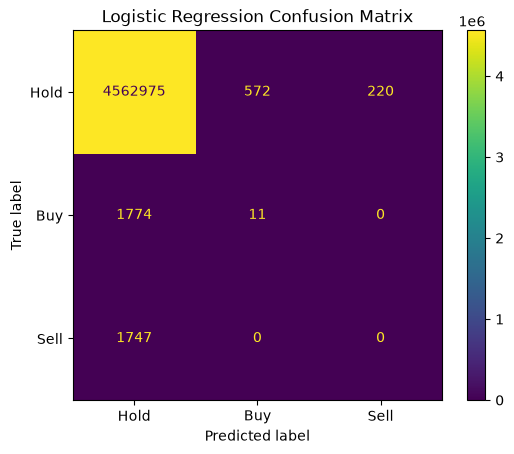

In [ ]:
# Logistic regression

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Hold", "Buy", "Sell"],
    values_format="d")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

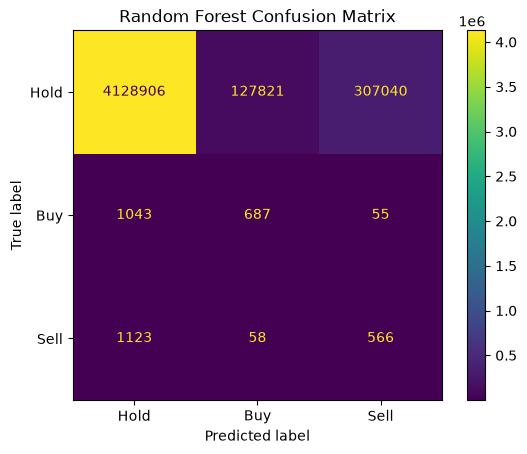

In [57]:
# Random forest

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Hold", "Buy", "Sell"],
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()
